# Module 3 — Firm-Level Response Prediction

This notebook evaluates whether policy exposure adds predictive information beyond financial variables and the chain-leader indicator. All supervised comparisons use expanding-window temporal validation.


## Setup — Imports and Shared Functions

Defines the feature sets, temporal folds, preprocessing pipeline, evaluation metrics and model factory used throughout the notebook.


In [1]:
# -*- coding: utf-8 -*-
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    log_loss,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
    adjusted_rand_score,
)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "XGBoost is required for this notebook. Install it with: pip install -U xgboost"
    ) from e

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_BOOT = 300

# Feature groups used in the two model specifications.
FINANCIAL_FEATURES = [
    "log_assets",
    "revenue_growth",
    "roa",
    "leverage",
    "cash_ratio",
    "rd_intensity",
    "capex_intensity",
    "interest_coverage",
]

POLICY_FEATURES = [
    "policy_exposure_primary",
    "lagged_policy_exposure",
]

# Keep the binary chain-leader indicator as the network input.
NETWORK_FEATURES = ["is_chain_leader"]

# The second feature set adds policy exposure to the baseline.
FEATURE_SETS = {
    "B1_Financial_ChainLeader":
        FINANCIAL_FEATURES + NETWORK_FEATURES,

    "B2_Financial_ChainLeader_Policy":
        FINANCIAL_FEATURES + NETWORK_FEATURES + POLICY_FEATURES,
}

# Expanding-window temporal validation.
FOLDS = [
    {"train_years": [2019, 2020], "test_year": 2021},
    {"train_years": [2019, 2020, 2021], "test_year": 2022},
    {"train_years": [2019, 2020, 2021, 2022], "test_year": 2023},
    {"train_years": [2019, 2020, 2021, 2022, 2023], "test_year": 2024},
]

GLOBAL_CLASSES = np.array([0, 1, 2], dtype=int)


def make_preprocessing_pipeline():
    """Fit median imputation and scaling on the training fold only."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])


def multiclass_brier(y_true, proba, classes=GLOBAL_CLASSES):
    y_true = np.asarray(y_true)
    y_onehot = np.zeros((len(y_true), len(classes)))
    for j, c in enumerate(classes):
        y_onehot[:, j] = (y_true == c).astype(int)
    return float(np.mean(np.sum((proba - y_onehot) ** 2, axis=1)))


def aligned_predict_proba(model, X, global_classes=GLOBAL_CLASSES):
    """Align model probabilities to class order [0,1,2]."""
    raw = model.predict_proba(X)
    model_classes = np.asarray(model.classes_, dtype=int)

    out = np.zeros((len(X), len(global_classes)), dtype=float)
    for j, c in enumerate(model_classes):
        pos = np.where(global_classes == c)[0]
        if len(pos) == 1:
            out[:, pos[0]] = raw[:, j]

    out = np.clip(out, 1e-12, 1.0)
    out = out / out.sum(axis=1, keepdims=True)
    return out


def evaluate_predictions(y_true, y_pred, proba):
    return {
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "log_loss": log_loss(
            y_true, proba, labels=GLOBAL_CLASSES
        ),
        "brier_score": multiclass_brier(
            y_true, proba, GLOBAL_CLASSES
        ),
    }


def bootstrap_mean_ci(values, n_boot=5000, seed=RANDOM_STATE, alpha=0.05):
    """Bootstrap CI for a vector of fold-level values."""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    if len(values) == 1:
        return float(values[0]), np.nan, np.nan

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    boot_means = values[idx].mean(axis=1)
    lo, hi = np.quantile(boot_means, [alpha / 2, 1 - alpha / 2])

    return float(values.mean()), float(lo), float(hi)


def make_model(model_family, params=None):
    """Build a classifier with the requested parameters."""
    params = {} if params is None else dict(params)

    if model_family == "LogisticRegression":
        defaults = dict(
            solver="lbfgs",
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE,
        )
        defaults.update(params)
        return LogisticRegression(**defaults)

    if model_family == "DecisionTree":
        defaults = dict(
            max_depth=8,
            min_samples_leaf=20,
            min_samples_split=20,
            criterion="gini",
            random_state=RANDOM_STATE,
        )
        defaults.update(params)
        return DecisionTreeClassifier(**defaults)

    if model_family == "RandomForest":
        defaults = dict(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        defaults.update(params)
        return RandomForestClassifier(**defaults)

    if model_family == "GradientBoosting":
        defaults = dict(
            n_estimators=220,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.90,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
        )
        defaults.update(params)
        return GradientBoostingClassifier(**defaults)

    if model_family == "XGBoost":
        defaults = dict(
            objective="multi:softprob",
            num_class=3,
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.90,
            colsample_bytree=0.90,
            min_child_weight=5,
            reg_lambda=1.0,
            reg_alpha=0.0,
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        defaults.update(params)
        return XGBClassifier(**defaults)

    raise ValueError(f"Unknown model family: {model_family}")


BASELINE_MODEL_FAMILIES = [
    "LogisticRegression",
    "DecisionTree",
    "RandomForest",
    "GradientBoosting",
    "XGBoost",
]

print("Feature sets:")
for k, v in FEATURE_SETS.items():
    print(f"  {k} ({len(v)} features): {v}")

print("\nBaseline model families:")
for m in BASELINE_MODEL_FAMILIES:
    print(" ", m)


Feature sets:
  B1_Financial_ChainLeader (9 features): ['log_assets', 'revenue_growth', 'roa', 'leverage', 'cash_ratio', 'rd_intensity', 'capex_intensity', 'interest_coverage', 'is_chain_leader']
  B2_Financial_ChainLeader_Policy (11 features): ['log_assets', 'revenue_growth', 'roa', 'leverage', 'cash_ratio', 'rd_intensity', 'capex_intensity', 'interest_coverage', 'is_chain_leader', 'policy_exposure_primary', 'lagged_policy_exposure']

Baseline model families:
  LogisticRegression
  DecisionTree
  RandomForest
  GradientBoosting
  XGBoost


## Part A — Build the Firm-Year Panel

Combines firm financials, industry policy exposure, the chain-leader indicator and next-year response labels. Features from year $t$ are aligned with the outcome in year $t+1$.


In [2]:
def load_module1_beta(path="module1_selected_model.json"):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def build_module3_dataset(
    financial_path="12_hybrid_financial_panel_1500_2019_2025.csv",
    exposure_path="industry_year_policy_exposure.csv",
    network_path="module2_firm_network_features.csv",
    labels_path="13_hybrid_module3_future_labels_2020_2025.csv",
    module1_json_path="module1_selected_model.json",
):
    """Merge financial, policy, network and next-year target data into one panel."""
    fin = pd.read_csv(financial_path, encoding="utf-8-sig")
    exposure = pd.read_csv(exposure_path, encoding="utf-8-sig")
    network = pd.read_csv(network_path, encoding="utf-8-sig")
    labels = pd.read_csv(labels_path, encoding="utf-8-sig")

    beta_model = load_module1_beta(module1_json_path)
    beta_hat = float(beta_model["beta_hat"])

    # Log-transform firm size before merging the feature layers.
    fin = fin.copy()
    fin["log_assets"] = np.log(
        fin["total_assets_mn_rmb"].clip(lower=1.0)
    )

    # Create the one-year policy-exposure lag within each industry.
    exposure = exposure.sort_values(
        ["industry_code", "year"]
    ).copy()

    exposure["lagged_policy_exposure"] = (
        exposure.groupby("industry_code")[
            "policy_exposure_primary"
        ].shift(1)
    )

    exposure_merge = exposure[
        [
            "industry_code",
            "year",
            "policy_exposure_primary",
            "lagged_policy_exposure",
        ]
    ]

    merged = fin.merge(
        exposure_merge,
        on=["industry_code", "year"],
        how="left",
    )

    merged["policy_exposure_primary"] = (
        merged["policy_exposure_primary"].fillna(0.0)
    )
    merged["lagged_policy_exposure"] = (
        merged["lagged_policy_exposure"].fillna(0.0)
    )

    # Keep the Module 1 effect for consistency checks; it is not a model feature.
    merged["module1_policy_effect"] = (
        beta_hat * merged["policy_exposure_primary"]
    )

    # Merge the binary chain-leader label from the network analysis.
    if "is_chain_leader" not in network.columns:
        raise KeyError(
            "module2_firm_network_features.csv must contain "
            "'is_chain_leader'."
        )

    network_small = (
        network[["firm_id", "is_chain_leader"]]
        .drop_duplicates("firm_id")
        .copy()
    )

    merged = merged.merge(
        network_small,
        on="firm_id",
        how="left",
    )
    merged["is_chain_leader"] = (
        merged["is_chain_leader"].fillna(0).astype(int)
    )

    # Align features at year t with the observed response at year t+1.
    labels_renamed = labels.rename(
        columns={"feature_year": "year"}
    )

    merged = merged.merge(
        labels_renamed[
            [
                "firm_id",
                "year",
                "outcome_year",
                "future_response_score",
                "target_class",
                "target_label",
            ]
        ],
        on=["firm_id", "year"],
        how="inner",
    )

    assert (
        merged["outcome_year"] == merged["year"] + 1
    ).all(), "Temporal alignment failed."

    merged["data_type"] = "HYBRID_METHOD_VALIDATION"
    return merged, beta_model


if Path("module3_final_firm_year_panel.csv").exists():
    df = pd.read_csv(
        "module3_final_firm_year_panel.csv",
        encoding="utf-8-sig",
    )
    print("Loaded existing module3_final_firm_year_panel.csv")
else:
    df, beta_model = build_module3_dataset()
    df.to_csv(
        "module3_final_firm_year_panel.csv",
        index=False,
        encoding="utf-8-sig",
    )
    print("Rebuilt and saved module3_final_firm_year_panel.csv")

print(f"Rows: {len(df):,}")
print(f"Firms: {df['firm_id'].nunique():,}")
print(f"Feature years: {sorted(df['year'].unique())}")


Loaded existing module3_final_firm_year_panel.csv
Rows: 9,000
Firms: 1,500
Feature years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [3]:
# Check the fields needed by the predictive pipeline.
required_cols = (
    ["firm_id", "year", "outcome_year", "target_class"]
    + FINANCIAL_FEATURES
    + POLICY_FEATURES
    + NETWORK_FEATURES
)

missing_required = [
    c for c in required_cols if c not in df.columns
]
if missing_required:
    raise KeyError(
        f"Missing required columns: {missing_required}"
    )

print(f"Firms: {df['firm_id'].nunique():,}")
print(f"Firm-year observations: {len(df):,}")
print(f"Years: {sorted(df['year'].unique())}")

print("\nTarget distribution:")
print(df["target_class"].value_counts().sort_index())
print(
    df["target_class"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nChain-leader distribution at firm level:")
firm_net = df[
    ["firm_id", "is_chain_leader"]
].drop_duplicates()
print(firm_net["is_chain_leader"].value_counts().sort_index())
print(
    firm_net["is_chain_leader"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

# Verify that every target belongs to the following year.
print("\nTemporal alignment:")
print(pd.crosstab(df["year"], df["outcome_year"]))
assert (
    df["outcome_year"] == df["year"] + 1
).all()

print("\nMissing-value rates:")
audit_features = (
    FINANCIAL_FEATURES
    + NETWORK_FEATURES
    + POLICY_FEATURES
)
print(
    df[audit_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .round(4)
)

assert set(
    firm_net["is_chain_leader"].dropna().astype(int).unique()
).issubset({0, 1})

print("\nPASS: target alignment and binary Chain-Leader interface are valid.")


Firms: 1,500
Firm-year observations: 9,000
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Target distribution:
target_class
0    2250
1    4500
2    2250
Name: count, dtype: int64
target_class
0    0.25
1    0.50
2    0.25
Name: proportion, dtype: float64

Chain-leader distribution at firm level:
is_chain_leader
0    1425
1      75
Name: count, dtype: int64
is_chain_leader
0    0.95
1    0.05
Name: proportion, dtype: float64

Temporal alignment:
outcome_year  2020  2021  2022  2023  2024  2025
year                                            
2019          1500     0     0     0     0     0
2020             0  1500     0     0     0     0
2021             0     0  1500     0     0     0
2022             0     0     0  1500     0     0
2023             0     0     0     0  1500     0
2024             0     0     0     0     0  1500

Missing-value rates:
revenue_growth             0.1667
log_assets                 0.0000
roa       

## Parts C — Baseline Benchmark and Policy Ablation

Compares the financial + chain-leader baseline with the policy-augmented feature set across five classifiers and four temporal folds. The fold-level difference measures the incremental contribution of policy information.


In [4]:
for name, feats in FEATURE_SETS.items():
    print(f"{name}: {len(feats)} features")


fold_rows = []
classreport_rows = []
bootstrap_pool = {}

for fset_name in FEATURE_SETS:
    for model_family in BASELINE_MODEL_FAMILIES:
        bootstrap_pool[(fset_name, model_family)] = {
            "macro_f1": [],
            "balanced_accuracy": [],
            "accuracy": [],
            "log_loss": [],
            "brier_score": [],
        }

t0 = time.time()

for fset_name, feat_cols in FEATURE_SETS.items():

    for fold_idx, fold in enumerate(FOLDS, start=1):

        train_mask = df["year"].isin(
            fold["train_years"]
        )
        test_mask = (
            df["year"] == fold["test_year"]
        )

        X_train_raw = df.loc[
            train_mask, feat_cols
        ].to_numpy()

        X_test_raw = df.loc[
            test_mask, feat_cols
        ].to_numpy()

        y_train = df.loc[
            train_mask, "target_class"
        ].to_numpy(dtype=int)

        y_test = df.loc[
            test_mask, "target_class"
        ].to_numpy(dtype=int)

        # Fit imputation and scaling on training years only.
        preproc = make_preprocessing_pipeline()
        X_train = preproc.fit_transform(X_train_raw)
        X_test = preproc.transform(X_test_raw)

        for model_family in BASELINE_MODEL_FAMILIES:

            model = make_model(model_family)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test).astype(int)
            proba = aligned_predict_proba(
                model, X_test
            )

            metrics = evaluate_predictions(
                y_test, y_pred, proba
            )

            fold_rows.append({
                "feature_set": fset_name,
                "model": model_family,
                "fold": fold_idx,
                "train_years": str(
                    fold["train_years"]
                ),
                "test_year": fold["test_year"],
                "n_train": len(y_train),
                "n_test": len(y_test),
                **metrics,
            })

            # Keep class-level diagnostics for later inspection.
            prec, rec, f1c, support = (
                precision_recall_fscore_support(
                    y_test,
                    y_pred,
                    labels=GLOBAL_CLASSES,
                    zero_division=0,
                )
            )

            for j, c in enumerate(GLOBAL_CLASSES):
                classreport_rows.append({
                    "feature_set": fset_name,
                    "model": model_family,
                    "fold": fold_idx,
                    "class": int(c),
                    "precision": float(prec[j]),
                    "recall": float(rec[j]),
                    "f1": float(f1c[j]),
                    "support": int(support[j]),
                })

            # Bootstrap held-out predictions without refitting the model.
            rng = np.random.default_rng(
                10_000 + fold_idx
            )
            n_test = len(y_test)

            for _ in range(N_BOOT):
                idx = rng.integers(
                    0, n_test, size=n_test
                )

                mb = evaluate_predictions(
                    y_test[idx],
                    y_pred[idx],
                    proba[idx],
                )

                for metric_name, value in mb.items():
                    bootstrap_pool[
                        (fset_name, model_family)
                    ][metric_name].append(value)

    print(
        f"{fset_name} finished; "
        f"elapsed={time.time() - t0:.1f}s"
    )

fold_results_df = pd.DataFrame(fold_rows)
fold_results_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)
fold_results_df.to_csv(
    "module3_fold_results.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame(classreport_rows).to_csv(
    "module3_classification_reports.csv",
    index=False,
    encoding="utf-8-sig",
)

# Summarise performance across the four temporal folds.
summary_rows = []

for (fset_name, model_family), pool in bootstrap_pool.items():

    fold_sub = fold_results_df[
        (fold_results_df["feature_set"] == fset_name)
        & (fold_results_df["model"] == model_family)
    ]

    row = {
        "feature_set": fset_name,
        "model": model_family,
        "macro_f1_mean": float(
            fold_sub["macro_f1"].mean()
        ),
        "macro_f1_std": float(
            fold_sub["macro_f1"].std(ddof=1)
        ),
        "balanced_accuracy_mean": float(
            fold_sub["balanced_accuracy"].mean()
        ),
        "accuracy_mean": float(
            fold_sub["accuracy"].mean()
        ),
        "log_loss_mean": float(
            fold_sub["log_loss"].mean()
        ),
        "brier_score_mean": float(
            fold_sub["brier_score"].mean()
        ),
    }

    # Retain bootstrap intervals as an uncertainty diagnostic.
    arr = np.asarray(
        pool["macro_f1"], dtype=float
    )
    row["macro_f1_ci_low"] = float(
        np.quantile(arr, 0.025)
    )
    row["macro_f1_ci_high"] = float(
        np.quantile(arr, 0.975)
    )

    summary_rows.append(row)

benchmark_df = (
    pd.DataFrame(summary_rows)
    .sort_values(
        "macro_f1_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

benchmark_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

benchmark_df.to_csv(
    "module3_model_benchmark.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nBaseline benchmark:")
print(
    benchmark_df[
        [
            "feature_set",
            "model",
            "macro_f1_mean",
            "macro_f1_std",
            "balanced_accuracy_mean",
            "accuracy_mean",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# Compare the policy-added feature set with the baseline.
pivot = fold_results_df.pivot_table(
    index=["model", "fold"],
    columns="feature_set",
    values="macro_f1",
)

BASE_SET = "B1_Financial_ChainLeader"
POLICY_SET = "B2_Financial_ChainLeader_Policy"

policy_rows = []

for model_family in (
    pivot.index.get_level_values("model").unique()
):

    sub = pivot.loc[model_family]

    delta = (
        sub[POLICY_SET]
        - sub[BASE_SET]
    )

    mean_delta, lo, hi = bootstrap_mean_ci(
        delta.to_numpy(),
        n_boot=5000,
        seed=RANDOM_STATE,
    )

    policy_rows.append({
        "model": model_family,
        "delta_type": "Delta_Policy",
        "mean_delta_macro_f1": mean_delta,
        "ci_low": lo,
        "ci_high": hi,
        "n_folds_positive": int(
            (delta > 0).sum()
        ),
        "n_folds_total": int(len(delta)),
        "sign_stable_across_folds": bool(
            (delta > 0).all()
            or (delta < 0).all()
        ),
    })

ablation_df = pd.DataFrame(policy_rows)
ablation_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

ablation_df.to_csv(
    "module3_ablation_results.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nIncremental policy contribution:")
print(
    ablation_df
    .sort_values(
        "mean_delta_macro_f1",
        ascending=False,
    )
    .round(4)
    .to_string(index=False)
)


B1_Financial_ChainLeader: 9 features
B2_Financial_ChainLeader_Policy: 11 features
B1_Financial_ChainLeader finished; elapsed=50.6s
B2_Financial_ChainLeader_Policy finished; elapsed=101.6s

Baseline benchmark:
                    feature_set              model  macro_f1_mean  macro_f1_std  balanced_accuracy_mean  accuracy_mean
B2_Financial_ChainLeader_Policy       RandomForest         0.6594        0.0264                  0.6436         0.6793
B2_Financial_ChainLeader_Policy            XGBoost         0.6555        0.0256                  0.6423         0.6732
B2_Financial_ChainLeader_Policy LogisticRegression         0.6545        0.0302                  0.6615         0.6587
B2_Financial_ChainLeader_Policy   GradientBoosting         0.6540        0.0279                  0.6421         0.6697
B2_Financial_ChainLeader_Policy       DecisionTree         0.6251        0.0249                  0.6142         0.6430
       B1_Financial_ChainLeader            XGBoost         0.5819        0.03

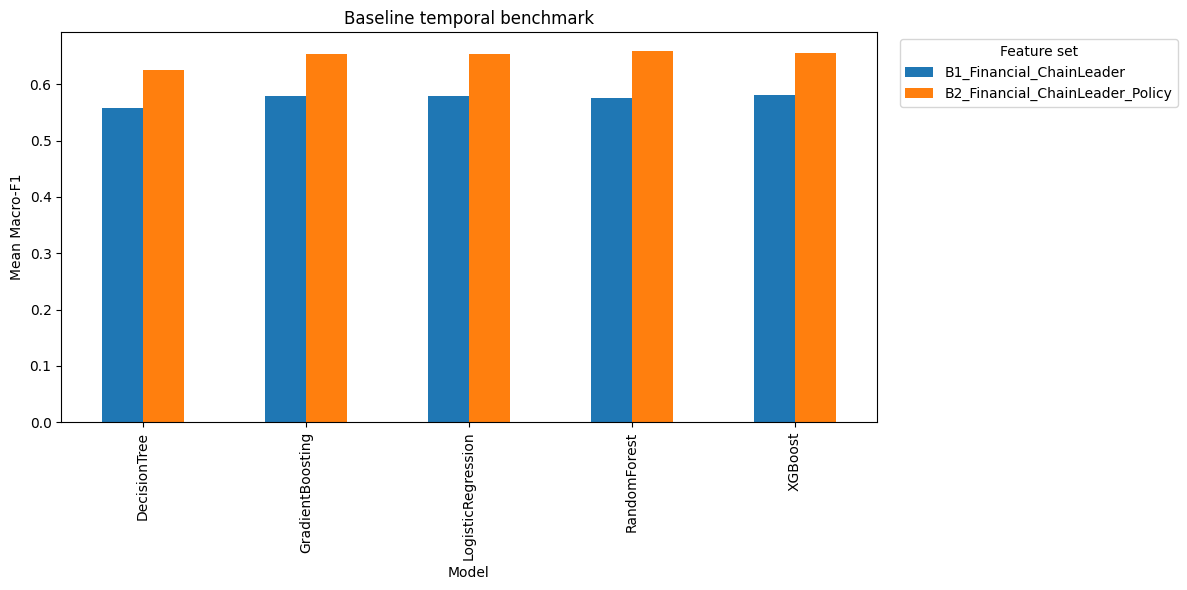

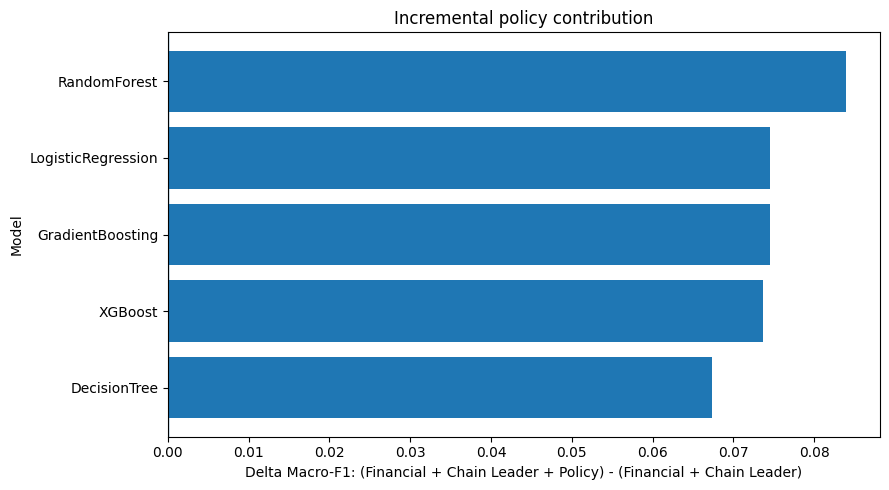

In [5]:
# Baseline model comparison
benchmark = pd.read_csv(
    "module3_model_benchmark.csv"
)

pivot_plot = benchmark.pivot(
    index="model",
    columns="feature_set",
    values="macro_f1_mean",
)

ax = pivot_plot.plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_title(
    "Baseline temporal benchmark"
)
ax.set_xlabel("Model")
ax.set_ylabel("Mean Macro-F1")
ax.legend(
    title="Feature set",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.savefig(
    "module3_fig1_baseline_benchmark.png",
    dpi=180,
)
plt.show()

# Incremental policy gain
abl = pd.read_csv(
    "module3_ablation_results.csv"
).sort_values(
    "mean_delta_macro_f1"
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)
ax.barh(
    abl["model"],
    abl["mean_delta_macro_f1"],
)
ax.axvline(0, linewidth=1)
ax.set_title(
    "Incremental policy contribution"
)
ax.set_xlabel(
    "Delta Macro-F1: "
    "(Financial + Chain Leader + Policy) "
    "- (Financial + Chain Leader)"
)
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(
    "module3_fig2_ablation.png",
    dpi=180,
)
plt.show()


## Part D — Focused Model Tuning

Random Forest and Logistic Regression are tuned on the same temporal folds. The tuned candidates are then compared with the original five baseline model families for final selection.


In [6]:
# Select the feature set using average Macro-F1 across model families.
feature_set_scores = (
    benchmark_df
    .groupby("feature_set", as_index=False)[
        "macro_f1_mean"
    ]
    .mean()
    .sort_values(
        "macro_f1_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

BEST_FEATURE_SET = str(
    feature_set_scores.iloc[0]["feature_set"]
)
BEST_FEATURES = FEATURE_SETS[
    BEST_FEATURE_SET
]

# Keep the baseline family ranking for the final comparison.
family_ranking = (
    benchmark_df[
        benchmark_df["feature_set"]
        == BEST_FEATURE_SET
    ]
    .sort_values(
        [
            "macro_f1_mean",
            "balanced_accuracy_mean",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nFeature-set ranking:")
print(
    feature_set_scores
    .round(4)
    .to_string(index=False)
)

print(
    f"\nSelected feature set: "
    f"{BEST_FEATURE_SET}"
)

print("\nBaseline model-family ranking inside selected feature set:")
print(
    family_ranking[
        [
            "model",
            "macro_f1_mean",
            "balanced_accuracy_mean",
            "accuracy_mean",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# Model-specific grids include the original RF and Logistic baselines.
TUNED_FAMILIES = [
    "RandomForest",
    "LogisticRegression",
]

TUNING_GRIDS = {
    "RandomForest": [
        {
            "n_estimators": [300, 400, 600],
            "max_depth": [8, 12, 16, None],
            "min_samples_leaf": [2, 5, 10],
            "min_samples_split": [2, 10],
            "max_features": ["sqrt", 0.7],
            "class_weight": [None],
        },
        {
            "n_estimators": [400, 600],
            "max_depth": [12, None],
            "min_samples_leaf": [3, 5],
            "min_samples_split": [5, 10],
            "max_features": ["sqrt"],
            "class_weight": [
                "balanced",
                "balanced_subsample",
            ],
        },
    ],

    "LogisticRegression": [
        {
            "solver": ["lbfgs"],
            "penalty": ["l2"],
            "C": [
                0.01, 0.03, 0.1,
                0.3, 1.0, 3.0,
                10.0, 30.0, 100.0,
            ],
            "class_weight": [
                None, "balanced"
            ],
        },
        {
            "solver": ["saga"],
            "penalty": ["l1", "l2"],
            "C": [
                0.01, 0.03, 0.1,
                0.3, 1.0, 3.0,
                10.0, 30.0, 100.0,
            ],
            "class_weight": [
                None, "balanced"
            ],
        },
        {
            "solver": ["saga"],
            "penalty": ["elasticnet"],
            "C": [
                0.03, 0.1, 0.3,
                1.0, 3.0, 10.0, 30.0,
            ],
            "l1_ratio": [
                0.25, 0.50, 0.75
            ],
            "class_weight": [
                None, "balanced"
            ],
        },
    ],
}


def temporal_score_candidate(
    model_family,
    params,
    feature_cols,
):
    """
    Evaluate one hyperparameter candidate on all expanding-window folds.
    """
    rows = []

    for fold_idx, fold in enumerate(
        FOLDS, start=1
    ):
        train_mask = df["year"].isin(
            fold["train_years"]
        )
        test_mask = (
            df["year"]
            == fold["test_year"]
        )

        X_train_raw = df.loc[
            train_mask, feature_cols
        ].to_numpy()

        X_test_raw = df.loc[
            test_mask, feature_cols
        ].to_numpy()

        y_train = df.loc[
            train_mask, "target_class"
        ].to_numpy(dtype=int)

        y_test = df.loc[
            test_mask, "target_class"
        ].to_numpy(dtype=int)

        preproc = make_preprocessing_pipeline()
        X_train = preproc.fit_transform(
            X_train_raw
        )
        X_test = preproc.transform(
            X_test_raw
        )

        model = make_model(
            model_family, params=params
        )
        model.fit(X_train, y_train)

        y_pred = model.predict(
            X_test
        ).astype(int)

        proba = aligned_predict_proba(
            model, X_test
        )

        metrics = evaluate_predictions(
            y_test, y_pred, proba
        )

        rows.append({
            "fold": fold_idx,
            "test_year": fold["test_year"],
            **metrics,
        })

    return pd.DataFrame(rows)


# Evaluate each candidate on the same expanding-window folds.
tuning_rows = []
tuning_fold_rows = []

search_start = time.time()

for model_family in TUNED_FAMILIES:

    grid = list(
        ParameterGrid(
            TUNING_GRIDS[model_family]
        )
    )

    print(
        f"\n{model_family}: "
        f"{len(grid)} hyperparameter candidates"
    )

    family_start = time.time()

    for candidate_id, params in enumerate(
        grid, start=1
    ):
        candidate_fold = temporal_score_candidate(
            model_family,
            params,
            BEST_FEATURES,
        )

        params_json = json.dumps(
            params,
            sort_keys=True,
        )

        for _, r in candidate_fold.iterrows():
            tuning_fold_rows.append({
                "candidate_id": candidate_id,
                "model_family": model_family,
                "feature_set": BEST_FEATURE_SET,
                "params_json": params_json,
                **r.to_dict(),
            })

        tuning_rows.append({
            "candidate_id": candidate_id,
            "model_family": model_family,
            "feature_set": BEST_FEATURE_SET,
            "params_json": params_json,
            "macro_f1_mean": float(
                candidate_fold[
                    "macro_f1"
                ].mean()
            ),
            "macro_f1_std": float(
                candidate_fold[
                    "macro_f1"
                ].std(ddof=1)
            ),
            "balanced_accuracy_mean": float(
                candidate_fold[
                    "balanced_accuracy"
                ].mean()
            ),
            "accuracy_mean": float(
                candidate_fold[
                    "accuracy"
                ].mean()
            ),
            "log_loss_mean": float(
                candidate_fold[
                    "log_loss"
                ].mean()
            ),
            "brier_score_mean": float(
                candidate_fold[
                    "brier_score"
                ].mean()
            ),
        })

        if (
            candidate_id == 1
            or candidate_id % 20 == 0
            or candidate_id == len(grid)
        ):
            print(
                f"  Candidate {candidate_id:>3}/"
                f"{len(grid)} completed"
            )

    print(
        f"  {model_family} finished in "
        f"{time.time() - family_start:.1f}s"
    )

tuning_df = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        [
            "model_family",
            "macro_f1_mean",
            "balanced_accuracy_mean",
        ],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

tuning_fold_df = pd.DataFrame(
    tuning_fold_rows
)

tuning_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)
tuning_fold_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

tuning_df.to_csv(
    "module3_refined_models.csv",
    index=False,
    encoding="utf-8-sig",
)

tuning_fold_df.to_csv(
    "module3_refined_fold_results.csv",
    index=False,
    encoding="utf-8-sig",
)

# Retain the best configuration from each tuned family.
best_tuned_rows = []

for model_family in TUNED_FAMILIES:

    family_tuning = (
        tuning_df[
            tuning_df["model_family"]
            == model_family
        ]
        .sort_values(
            [
                "macro_f1_mean",
                "balanced_accuracy_mean",
            ],
            ascending=False,
        )
        .reset_index(drop=True)
    )

    best_row = family_tuning.iloc[0]

    baseline_row = (
        family_ranking[
            family_ranking["model"]
            == model_family
        ]
        .iloc[0]
    )

    best_tuned_rows.append({
        "model_family": model_family,
        "feature_set": BEST_FEATURE_SET,
        "candidate_id": int(
            best_row["candidate_id"]
        ),
        "params_json": best_row[
            "params_json"
        ],
        "baseline_macro_f1": float(
            baseline_row["macro_f1_mean"]
        ),
        "tuned_macro_f1": float(
            best_row["macro_f1_mean"]
        ),
        "delta_vs_baseline_macro_f1": float(
            best_row["macro_f1_mean"]
            - baseline_row["macro_f1_mean"]
        ),
        "macro_f1_std": float(
            best_row["macro_f1_std"]
        ),
        "balanced_accuracy_mean": float(
            best_row[
                "balanced_accuracy_mean"
            ]
        ),
        "accuracy_mean": float(
            best_row["accuracy_mean"]
        ),
        "log_loss_mean": float(
            best_row["log_loss_mean"]
        ),
        "brier_score_mean": float(
            best_row["brier_score_mean"]
        ),
    })

tuned_summary_df = pd.DataFrame(
    best_tuned_rows
)

tuned_summary_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

tuned_summary_df.to_csv(
    "module3_tuned_model_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nBest tuned configuration by family:")
print(
    tuned_summary_df[
        [
            "model_family",
            "baseline_macro_f1",
            "tuned_macro_f1",
            "delta_vs_baseline_macro_f1",
            "balanced_accuracy_mean",
            "accuracy_mean",
            "params_json",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

# Compare tuned candidates with all untouched baseline families.
final_candidate_rows = []

for _, r in family_ranking.iterrows():
    final_candidate_rows.append({
        "candidate_source": "baseline",
        "model_family": str(
            r["model"]
        ),
        "feature_set": BEST_FEATURE_SET,
        "params_json": json.dumps({}),
        "macro_f1_mean": float(
            r["macro_f1_mean"]
        ),
        "macro_f1_std": float(
            r["macro_f1_std"]
        ),
        "balanced_accuracy_mean": float(
            r["balanced_accuracy_mean"]
        ),
        "accuracy_mean": float(
            r["accuracy_mean"]
        ),
        "log_loss_mean": float(
            r["log_loss_mean"]
        ),
        "brier_score_mean": float(
            r["brier_score_mean"]
        ),
    })

for _, r in tuned_summary_df.iterrows():
    final_candidate_rows.append({
        "candidate_source": "tuned_grid",
        "model_family": str(
            r["model_family"]
        ),
        "feature_set": BEST_FEATURE_SET,
        "params_json": r[
            "params_json"
        ],
        "macro_f1_mean": float(
            r["tuned_macro_f1"]
        ),
        "macro_f1_std": float(
            r["macro_f1_std"]
        ),
        "balanced_accuracy_mean": float(
            r["balanced_accuracy_mean"]
        ),
        "accuracy_mean": float(
            r["accuracy_mean"]
        ),
        "log_loss_mean": float(
            r["log_loss_mean"]
        ),
        "brier_score_mean": float(
            r["brier_score_mean"]
        ),
    })

final_candidates_df = (
    pd.DataFrame(final_candidate_rows)
    .sort_values(
        [
            "macro_f1_mean",
            "balanced_accuracy_mean",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

final_candidates_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

final_candidates_df.to_csv(
    "module3_final_model_candidates.csv",
    index=False,
    encoding="utf-8-sig",
)

winner = final_candidates_df.iloc[0]
BEST_MODEL_FAMILY = str(
    winner["model_family"]
)
BEST_PARAMS = json.loads(
    winner["params_json"]
)

SELECTED = {
    "source": str(
        winner["candidate_source"]
    ),
    "feature_set": BEST_FEATURE_SET,
    "model": BEST_MODEL_FAMILY,
    "model_family": BEST_MODEL_FAMILY,
    "params": BEST_PARAMS,
    "macro_f1_mean": float(
        winner["macro_f1_mean"]
    ),
    "balanced_accuracy_mean": float(
        winner["balanced_accuracy_mean"]
    ),
    "selection_rule": (
        "Highest mean Macro-F1 on the common expanding-window "
        "temporal folds after expanded tuning of Random Forest "
        "and Logistic Regression; all five baseline families "
        "remain eligible. Balanced Accuracy is used only as a "
        "tie-breaker."
    ),
    "data_type": "HYBRID_METHOD_VALIDATION",
}

with open(
    "module3_selected_model.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        SELECTED,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(
    f"\nExpanded tuning finished in "
    f"{time.time() - search_start:.1f}s"
)

print("\nTop final model candidates:")
print(
    final_candidates_df[
        [
            "candidate_source",
            "model_family",
            "macro_f1_mean",
            "macro_f1_std",
            "balanced_accuracy_mean",
            "accuracy_mean",
            "params_json",
        ]
    ]
    .head(10)
    .round(4)
    .to_string(index=False)
)

print("\nSelected model:")
print(
    json.dumps(
        SELECTED,
        indent=2,
        ensure_ascii=False,
    )
)



Feature-set ranking:
                    feature_set  macro_f1_mean
B2_Financial_ChainLeader_Policy         0.6497
       B1_Financial_ChainLeader         0.5749

Selected feature set: B2_Financial_ChainLeader_Policy

Baseline model-family ranking inside selected feature set:
             model  macro_f1_mean  balanced_accuracy_mean  accuracy_mean
      RandomForest         0.6594                  0.6436         0.6793
           XGBoost         0.6555                  0.6423         0.6732
LogisticRegression         0.6545                  0.6615         0.6587
  GradientBoosting         0.6540                  0.6421         0.6697
      DecisionTree         0.6251                  0.6142         0.6430

RandomForest: 176 hyperparameter candidates
  Candidate   1/176 completed
  Candidate  20/176 completed
  Candidate  40/176 completed
  Candidate  60/176 completed
  Candidate  80/176 completed
  Candidate 100/176 completed
  Candidate 120/176 completed
  Candidate 140/176 completed

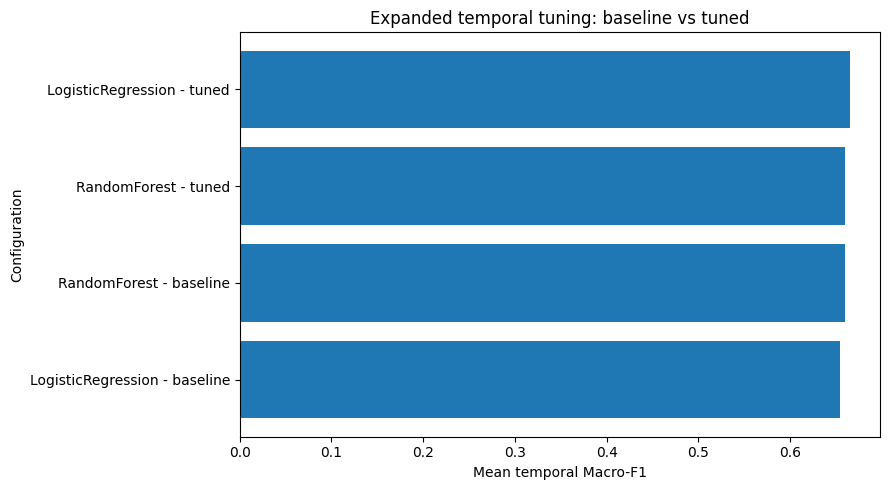

In [7]:
# Baseline versus tuned RF and Logistic performance
tuned_cmp = pd.read_csv(
    "module3_tuned_model_summary.csv"
)

plot_rows = []

for _, r in tuned_cmp.iterrows():
    plot_rows.append({
        "label": (
            f"{r['model_family']} - baseline"
        ),
        "macro_f1": r[
            "baseline_macro_f1"
        ],
    })
    plot_rows.append({
        "label": (
            f"{r['model_family']} - tuned"
        ),
        "macro_f1": r[
            "tuned_macro_f1"
        ],
    })

plot_df = pd.DataFrame(
    plot_rows
).sort_values(
    "macro_f1",
    ascending=True,
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    plot_df["label"],
    plot_df["macro_f1"],
)

ax.set_title(
    "Expanded temporal tuning: baseline vs tuned"
)
ax.set_xlabel(
    "Mean temporal Macro-F1"
)
ax.set_ylabel("Configuration")
plt.tight_layout()
plt.savefig(
    "module3_fig6_refined_models.png",
    dpi=180,
)
plt.show()


## Part E — Permutation Importance

Uses the 2024 holdout to measure how much Macro-F1 changes when each feature is shuffled while the selected model remains fixed.


In [8]:
with open(
    "module3_selected_model.json",
    "r",
    encoding="utf-8",
) as f:
    selected = json.load(f)

SELECTED_FEATURE_SET = selected[
    "feature_set"
]
SELECTED_FEATURES = FEATURE_SETS[
    SELECTED_FEATURE_SET
]
SELECTED_MODEL_FAMILY = selected[
    "model_family"
]
SELECTED_PARAMS = selected["params"]

print(
    f"Feature set: {SELECTED_FEATURE_SET}"
)
print(
    f"Model family: {SELECTED_MODEL_FAMILY}"
)
print(
    f"Parameters: {SELECTED_PARAMS}"
)

# Use the latest temporal holdout for model interpretation.
train_mask = df["year"].isin(
    [2019, 2020, 2021, 2022, 2023]
)
test_mask = df["year"] == 2024

X_train_raw = df.loc[
    train_mask, SELECTED_FEATURES
].to_numpy()

X_test_raw = df.loc[
    test_mask, SELECTED_FEATURES
].to_numpy()

y_train = df.loc[
    train_mask, "target_class"
].to_numpy(dtype=int)

y_test = df.loc[
    test_mask, "target_class"
].to_numpy(dtype=int)

preproc = make_preprocessing_pipeline()
X_train = preproc.fit_transform(
    X_train_raw
)
X_test = preproc.transform(
    X_test_raw
)

model = make_model(
    SELECTED_MODEL_FAMILY,
    SELECTED_PARAMS,
)
model.fit(X_train, y_train)

perm = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance_mean":
        perm.importances_mean,
    "importance_std":
        perm.importances_std,
}).sort_values(
    "importance_mean",
    ascending=False,
)

importance_df["feature_layer"] = np.select(
    [
        importance_df["feature"].isin(
            FINANCIAL_FEATURES
        ),
        importance_df["feature"].isin(
            POLICY_FEATURES
        ),
        importance_df["feature"].isin(
            NETWORK_FEATURES
        ),
    ],
    [
        "Financial",
        "Policy",
        "ChainLeader",
    ],
    default="Other",
)

importance_df["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

importance_df.to_csv(
    "module3_permutation_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    importance_df
    .round(5)
    .to_string(index=False)
)


Feature set: B2_Financial_ChainLeader_Policy
Model family: LogisticRegression
Parameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}
                feature  importance_mean  importance_std feature_layer                data_type
policy_exposure_primary          0.29515         0.01121        Policy HYBRID_METHOD_VALIDATION
                    roa          0.08966         0.01092     Financial HYBRID_METHOD_VALIDATION
         revenue_growth          0.06066         0.00696     Financial HYBRID_METHOD_VALIDATION
 lagged_policy_exposure          0.04431         0.00961        Policy HYBRID_METHOD_VALIDATION
           rd_intensity          0.02739         0.00697     Financial HYBRID_METHOD_VALIDATION
      interest_coverage          0.02202         0.00577     Financial HYBRID_METHOD_VALIDATION
        is_chain_leader          0.01241         0.00301   ChainLeader HYBRID_METHOD_VALIDATION
             cash_ratio          0.00841         0.00601     Financial HYB

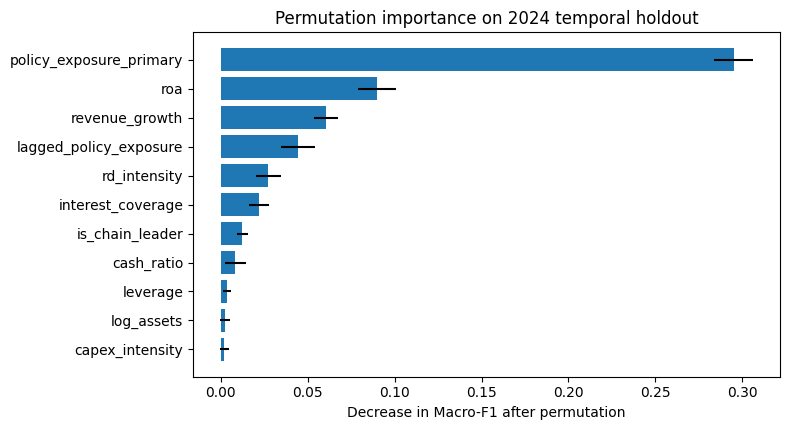

In [9]:
# Permutation importance on the 2024 holdout
imp = (
    pd.read_csv(
        "module3_permutation_importance.csv"
    )
    .sort_values("importance_mean")
)

fig, ax = plt.subplots(
    figsize=(
        8,
        max(4, 0.4 * len(imp))
    )
)

ax.barh(
    imp["feature"],
    imp["importance_mean"],
    xerr=imp["importance_std"],
)

ax.set_title(
    "Permutation importance on 2024 temporal holdout"
)
ax.set_xlabel(
    "Decrease in Macro-F1 after permutation"
)
plt.tight_layout()
plt.savefig(
    "module3_fig4_permutation_importance.png",
    dpi=180,
)
plt.show()


## Part F — Exploratory KMeans Segmentation

Clusters firms in the latest feature-year snapshot without using the future response label. Silhouette and stability guide the choice of $k$; target agreement is checked only afterwards.


In [10]:
snapshot_year = int(df["year"].max())

snapshot = (
    df[df["year"] == snapshot_year]
    .copy()
    .reset_index(drop=True)
)

# Cluster the latest snapshot using the full feature space.
cluster_features = (
    FINANCIAL_FEATURES
    + NETWORK_FEATURES
    + POLICY_FEATURES
)

preproc = make_preprocessing_pipeline()
X_cluster = preproc.fit_transform(
    snapshot[cluster_features].to_numpy()
)

rows = []
clusterings = {}

for k in range(2, 8):

    km = KMeans(
        n_clusters=k,
        n_init="auto",
        random_state=RANDOM_STATE,
    )

    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(
        X_cluster, labels
    )

    stability = []

    for seed in range(10):
        km_s = KMeans(
            n_clusters=k,
            n_init="auto",
            random_state=100 + seed,
        )
        labels_s = km_s.fit_predict(
            X_cluster
        )
        stability.append(
            adjusted_rand_score(
                labels, labels_s
            )
        )

    # Target labels are used only as an external comparison.
    target_ari = adjusted_rand_score(
        snapshot["target_class"],
        labels,
    )

    rows.append({
        "k": k,
        "silhouette": sil,
        "stability_ari_mean":
            float(np.mean(stability)),
        "stability_ari_min":
            float(np.min(stability)),
        "ari_vs_future_target_exploratory":
            target_ari,
    })

    clusterings[k] = labels

kmeans_eval = pd.DataFrame(rows)

best_k = int(
    kmeans_eval
    .sort_values(
        [
            "silhouette",
            "stability_ari_mean",
        ],
        ascending=False,
    )
    .iloc[0]["k"]
)

snapshot["cluster_id"] = (
    clusterings[best_k]
)

snapshot["cluster_label"] = (
    "Segment_"
    + snapshot["cluster_id"].astype(str)
)

segment_cols = [
    "firm_id",
    "year",
    "industry_code",
    "cluster_id",
    "cluster_label",
    "is_chain_leader",
    "target_class",
]

snapshot[segment_cols].to_csv(
    "module3_kmeans_firm_segments.csv",
    index=False,
    encoding="utf-8-sig",
)

profile = (
    snapshot
    .groupby(
        ["cluster_id", "cluster_label"]
    )[cluster_features]
    .mean()
    .reset_index()
)

size_map = (
    snapshot
    .groupby("cluster_id")
    .size()
)

profile["n_firms"] = (
    profile["cluster_id"]
    .map(size_map)
)

profile.to_csv(
    "module3_kmeans_cluster_profiles.csv",
    index=False,
    encoding="utf-8-sig",
)

kmeans_eval["selected_k"] = (
    kmeans_eval["k"].eq(best_k)
)
kmeans_eval["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

kmeans_eval.to_csv(
    "module3_kmeans_evaluation.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    kmeans_eval
    .round(4)
    .to_string(index=False)
)
print(f"\nSelected k = {best_k}")


 k  silhouette  stability_ari_mean  stability_ari_min  ari_vs_future_target_exploratory  selected_k                data_type
 2      0.2372              0.9869             0.9813                            0.1595        True HYBRID_METHOD_VALIDATION
 3      0.1909              0.5741             0.2617                            0.1117       False HYBRID_METHOD_VALIDATION
 4      0.2019              0.6695             0.3276                            0.0894       False HYBRID_METHOD_VALIDATION
 5      0.1712              0.4691             0.3109                            0.0914       False HYBRID_METHOD_VALIDATION
 6      0.1681              0.8513             0.5470                            0.0728       False HYBRID_METHOD_VALIDATION
 7      0.1624              0.6397             0.5118                            0.0725       False HYBRID_METHOD_VALIDATION

Selected k = 2


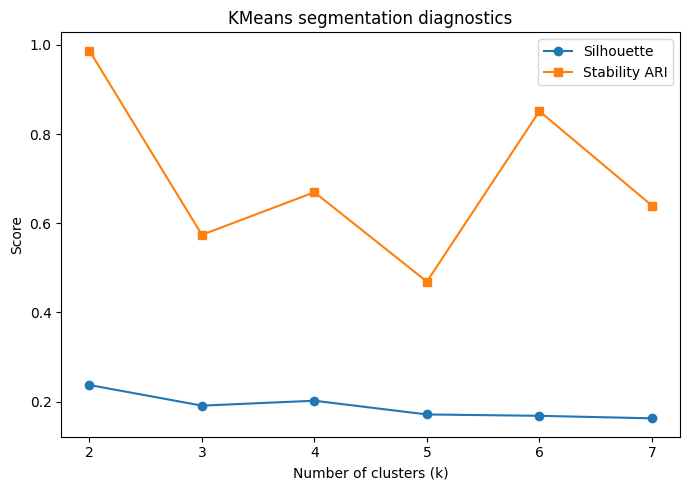

In [11]:
# KMeans diagnostics
km = pd.read_csv(
    "module3_kmeans_evaluation.csv"
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    km["k"],
    km["silhouette"],
    marker="o",
    label="Silhouette",
)

ax.plot(
    km["k"],
    km["stability_ari_mean"],
    marker="s",
    label="Stability ARI",
)

ax.set_title(
    "KMeans segmentation diagnostics"
)
ax.set_xlabel(
    "Number of clusters (k)"
)
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.savefig(
    "module3_fig5_kmeans.png",
    dpi=180,
)
plt.show()


## Part G — Out-of-Fold Predictions

Reconstructs the selected model across the expanding-window folds and produces out-of-fold predictions for the downstream robustness analysis.


In [12]:
with open(
    "module3_selected_model.json",
    "r",
    encoding="utf-8",
) as f:
    selected = json.load(f)

selected_feature_set = selected[
    "feature_set"
]
selected_features = FEATURE_SETS[
    selected_feature_set
]
selected_model_family = selected[
    "model_family"
]
selected_params = selected["params"]

print(
    f"Feature set: {selected_feature_set}"
)
print(
    f"Model: {selected_model_family}"
)
print(
    f"Parameters: {selected_params}"
)

oof_parts = []
selected_fold_rows = []

# Refit the selected configuration in each temporal fold.
for fold_idx, fold in enumerate(
    FOLDS, start=1
):

    train_mask = df["year"].isin(
        fold["train_years"]
    )
    test_mask = (
        df["year"] == fold["test_year"]
    )

    X_train_raw = df.loc[
        train_mask, selected_features
    ].to_numpy()

    X_test_raw = df.loc[
        test_mask, selected_features
    ].to_numpy()

    y_train = df.loc[
        train_mask, "target_class"
    ].to_numpy(dtype=int)

    y_test = df.loc[
        test_mask, "target_class"
    ].to_numpy(dtype=int)

    preproc = make_preprocessing_pipeline()
    X_train = preproc.fit_transform(
        X_train_raw
    )
    X_test = preproc.transform(
        X_test_raw
    )

    model = make_model(
        selected_model_family,
        selected_params,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(
        X_test
    ).astype(int)

    proba = aligned_predict_proba(
        model, X_test
    )

    metrics = evaluate_predictions(
        y_test, y_pred, proba
    )

    selected_fold_rows.append({
        "fold": fold_idx,
        "test_year": fold["test_year"],
        **metrics,
    })

    part = pd.DataFrame({
        "firm_id": df.loc[
            test_mask, "firm_id"
        ].to_numpy(),

        "year": df.loc[
            test_mask, "year"
        ].to_numpy(),

        "outcome_year": df.loc[
            test_mask, "outcome_year"
        ].to_numpy(),

        "true_class": y_test,
        "predicted_class": y_pred,
        "fold": fold_idx,
    })

    for j, c in enumerate(
        GLOBAL_CLASSES
    ):
        part[
            f"proba_class_{int(c)}"
        ] = proba[:, j]

    # Keep policy and chain-leader fields for downstream robustness tests.
    part["is_chain_leader"] = (
        df.loc[
            test_mask,
            "is_chain_leader"
        ].to_numpy()
    )

    part["policy_exposure_primary"] = (
        df.loc[
            test_mask,
            "policy_exposure_primary"
        ].to_numpy()
    )

    part["lagged_policy_exposure"] = (
        df.loc[
            test_mask,
            "lagged_policy_exposure"
        ].to_numpy()
    )

    oof_parts.append(part)

oof = pd.concat(
    oof_parts,
    ignore_index=True,
)

oof["data_type"] = (
    "HYBRID_METHOD_VALIDATION"
)

selected_fold_df = pd.DataFrame(
    selected_fold_rows
)

selected_fold_df.to_csv(
    "module3_selected_fold_results.csv",
    index=False,
    encoding="utf-8-sig",
)

macro_f1_oof = f1_score(
    oof["true_class"],
    oof["predicted_class"],
    average="macro",
    zero_division=0,
)

bal_acc_oof = balanced_accuracy_score(
    oof["true_class"],
    oof["predicted_class"],
)

acc_oof = accuracy_score(
    oof["true_class"],
    oof["predicted_class"],
)

oof.to_csv(
    "module3_best_model_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nSelected-model fold performance:")
print(
    selected_fold_df
    .round(4)
    .to_string(index=False)
)

print(f"\nOOF rows = {len(oof):,}")
print(
    f"OOF Macro-F1 = "
    f"{macro_f1_oof:.4f}"
)
print(
    f"OOF Balanced Accuracy = "
    f"{bal_acc_oof:.4f}"
)
print(
    f"OOF Accuracy = "
    f"{acc_oof:.4f}"
)

print("\nPooled classification report:")
print(
    classification_report(
        oof["true_class"],
        oof["predicted_class"],
        digits=4,
        zero_division=0,
    )
)

print(
    "\nSaved: "
    "module3_best_model_predictions.csv"
)


Feature set: B2_Financial_ChainLeader_Policy
Model: LogisticRegression
Parameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}

Selected-model fold performance:
 fold  test_year  macro_f1  balanced_accuracy  accuracy  log_loss  brier_score
    1       2021    0.6269             0.6592    0.6287    0.8088       0.4919
    2       2022    0.6616             0.6559    0.6760    0.7216       0.4511
    3       2023    0.6930             0.6873    0.7000    0.6924       0.4234
    4       2024    0.6777             0.6687    0.6747    0.6650       0.4270

OOF rows = 6,000
OOF Macro-F1 = 0.6664
OOF Balanced Accuracy = 0.6614
OOF Accuracy = 0.6698

Pooled classification report:
              precision    recall  f1-score   support

           0     0.6860    0.6056    0.6433      1169
           1     0.6636    0.6711    0.6673      2928
           2     0.6707    0.7073    0.6885      1903

    accuracy                         0.6698      6000
   macro avg     0.6734 

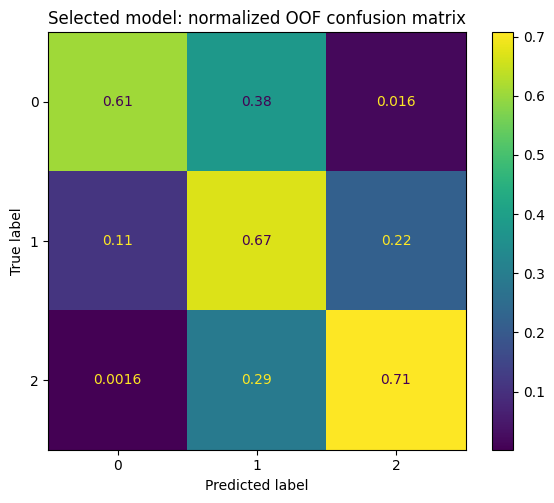

In [13]:
# Normalized OOF confusion matrix
oof = pd.read_csv(
    "module3_best_model_predictions.csv"
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    oof["true_class"],
    oof["predicted_class"],
    normalize="true",
    ax=ax,
)

ax.set_title(
    "Selected model: normalized OOF confusion matrix"
)
plt.tight_layout()
plt.savefig(
    "module3_fig3_confusion_matrix.png",
    dpi=180,
)
plt.show()
